# Calculus

### Notations

#### Slope = infinitesimal change in vertical / infinitesimal change in horizontal. i.e., dy / dx

#### Lets say, y = f(x)

#### derivative can be expressed as f'(x) --> Lagrange's notation
#### Also as dy/dx OR df(x)/dx --> Leibniz notation.

In [1]:
import numpy as np
import time

# t = time samples, d = distance traveled.
t = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60])
x_arr = np.array([0,36,122,202,275,351,441,551,591,716,816,900,1000])

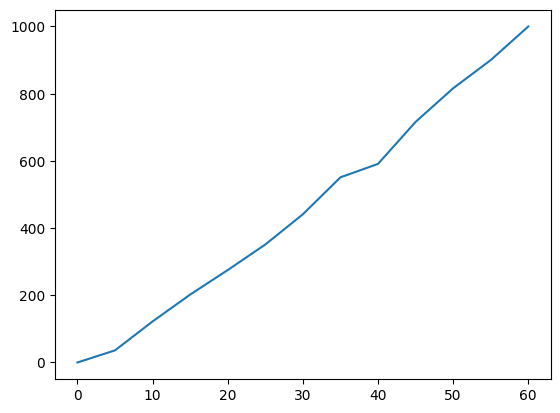

In [2]:
import matplotlib.pyplot as plt

plt.plot(t, x_arr)
plt.show()

In [3]:
# slope = rise / run

# avg vel between t = 10 --> 15
slope = (x_arr[3] - x_arr[2]) / (t[3] - t[2])
print(slope)

16.0


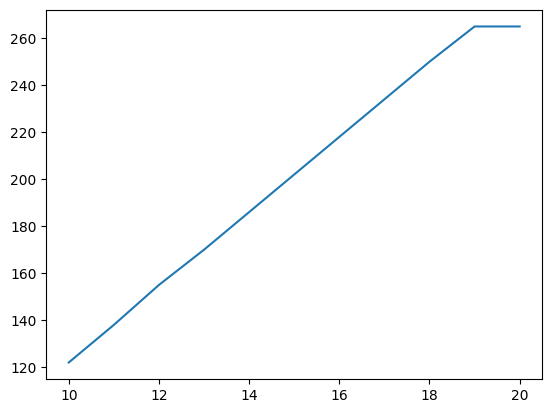

In [4]:
# more refined data between 10 - 20s
t = np.arange(10, 21, 1)
x_arr = np.array([122,138,155,170,186,202,218,234,250,265,265])

plt.plot(t, x_arr)
plt.show()

In [5]:
# avg vel between t = 12 --> 13
slope = (x_arr[3] - x_arr[2]) / (t[3] - t[2])
print(slope)

15.0


## derivative is dx/dt (infinitesimal slope of tangent at any point)

In [6]:
# new data between 0 - 120s
t = np.arange(0, 120, 5)
x_arr = np.sin(np.linspace(0, 300, 24))

In [7]:
print(t)
print(x_arr)

[  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115]
[ 0.          0.45921174  0.81586024  0.99028934  0.94354097  0.68605619
  0.27534329 -0.19686653 -0.62510693 -0.913732   -0.99827838 -0.85986297
 -0.52940032 -0.08069806  0.38602782  0.7665358   0.97584083  0.9671954
  0.74253044  0.35202403 -0.11710564 -0.56008021 -0.87796292 -0.99975584]


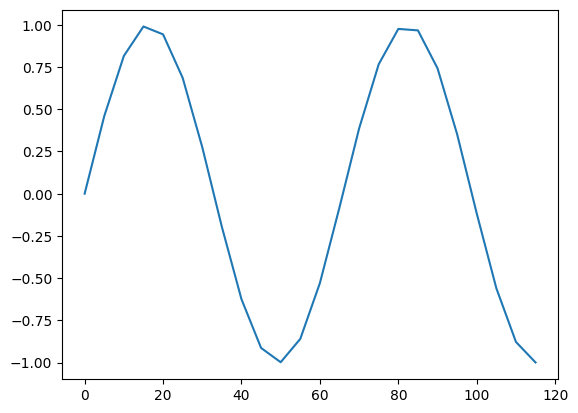

In [8]:
plt.plot(t, x_arr)
plt.show()

In [9]:
v = np.zeros_like(x_arr)

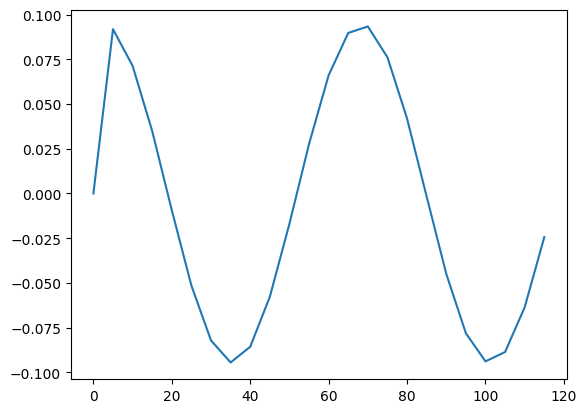

In [10]:
for i in range(1, len(v)):
    v[i] = (x_arr[i]-x_arr[i-1]) / (t[i]-t[i-1])

plt.plot(t, v)
plt.show()

## DIY differentiation

In [11]:
def f(x):
    return x**2

def dfdx(x):
    return 2*x

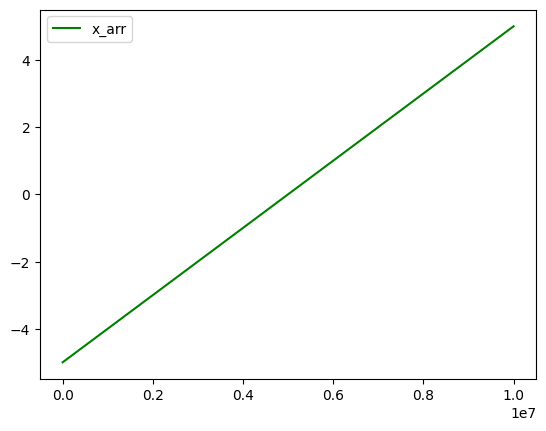

In [12]:
x_arr = np.linspace(-5, 5, 10000000)

plt.plot(x_arr, 'g', label="x_arr")
plt.legend()
plt.show()

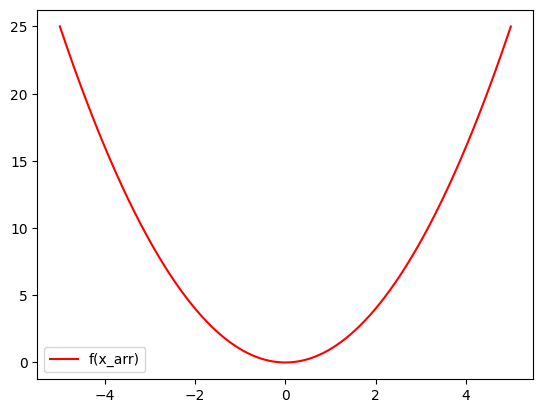

In [13]:
plt.plot(x_arr, f(x_arr), 'r', label="f(x_arr)")
plt.legend()
plt.show()

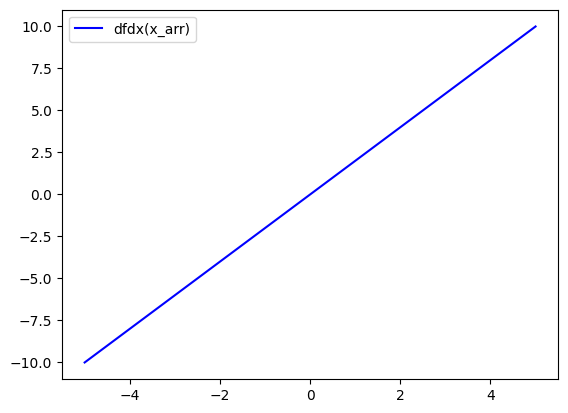

In [14]:
plt.plot(x_arr, dfdx(x_arr), 'b', label="dfdx(x_arr)")
plt.legend()
plt.show()

## Symbols with python (Sympy)

In [15]:
from sympy import *

sqrt(18)

3*sqrt(2)

In [16]:
N(sqrt(18),6)

4.24264

In [17]:
# List of symbols.
x, y = symbols('x y')
# Definition of the expression.
expr = 2 * x**2 - x * y
expr

2*x**2 - x*y

In [18]:
expr = x * (expr + x * y + x**3)
expr

x*(x**3 + 2*x**2)

In [19]:
expand(expr)

x**4 + 2*x**3

In [20]:
factor(expr)

x**3*(x + 2)

In [21]:
expr.evalf(subs={x:-1, y:2})

-1.00000000000000

In [22]:
f = x**2
f.evalf(subs={x:3})

9.00000000000000

---------

##  Symbolic differentiation
### Symbolic computation deals with the computation of mathematical objects that are represented exactly.

In [23]:
#f = x**2
#f = 2*x**3 - 3*x**2 + 5
f = sin(exp(x**2)) + log(x**2 + 1)
f

log(x**2 + 1) + sin(exp(x**2))

In [24]:
df = diff(f, x)
df

2*x*exp(x**2)*cos(exp(x**2)) + 2*x/(x**2 + 1)

In [25]:
from sympy.utilities.lambdify import lambdify
df_np = lambdify(x, df, 'numpy')

237.2584342956543


C:\Users\mdame\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


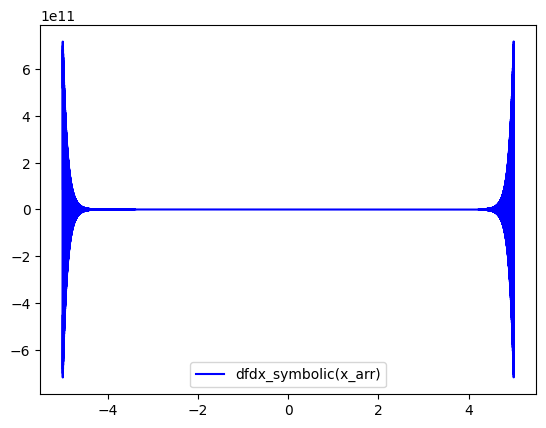

In [26]:
start = time.time()
dfdx_symbolic = df_np(x_arr)
stop = time.time()

print(1000 * (stop - start))

plt.plot(x_arr, dfdx_symbolic, 'b', label="dfdx_symbolic(x_arr)")
plt.legend()
plt.show()

------------------

## Numerical differentiation

### This method does not take into account the function expression. The only important thing is that the function can be evaluated in the nearby points 𝑥 and 𝑥+Δ𝑥, where Δ𝑥 is sufficiently small. Then 𝑑𝑓𝑑𝑥≈𝑓(𝑥+Δ𝑥)−𝑓(𝑥)Δ𝑥, which can be called a numerical approximation of the derivative. 

344.30432319641113


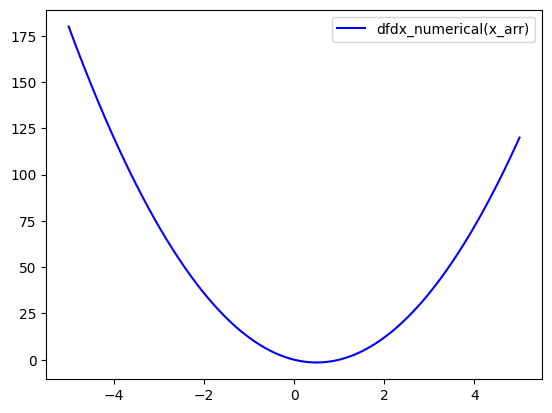

In [27]:
def f_n(x):
    #return x**2
    # skip, too slow return sin(exp(x**2)) + log(x**2 + 1)
    return 2*x**3 - 3*x**2 + 5
    
    
start_n = time.time()
dfdx_numerical = np.gradient(f_n(x_arr), x_arr)
stop_n = time.time()

print(1000 * (stop_n - start_n))

plt.plot(x_arr, dfdx_numerical, 'b', label="dfdx_numerical(x_arr)")
plt.legend()
plt.show()

## Automatic Differentiation
### Automatic differentiation (autodiff) method breaks down the function into common functions (𝑠𝑖𝑛, 𝑐𝑜𝑠, 𝑙𝑜𝑔, power functions, etc.), and constructs the computational graph consisting of the basic functions. Then the chain rule is used to compute the derivative at any node of the graph.
### However, nowadays there are libraries that are convenient to use, such as MyGrad, Autograd and JAX. 

In [46]:
from jax import grad, vmap, jit, make_jaxpr
import jax.numpy as jnp

In [47]:
def f_a(x):
    #return x**2
    #return 2*x**3 - 3*x**2 + 5
    return jnp.sin(jnp.exp(x**2)) + jnp.log(x**2 + 1)

x_arr_jnp = jnp.linspace(-5, 5, 10000000)

35.242319107055664


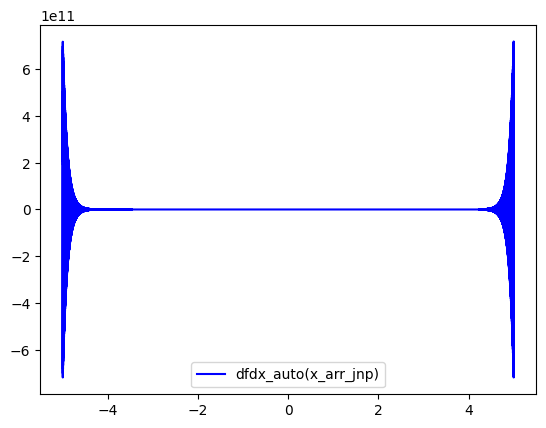

In [48]:
start_a = time.time()

dfdx_auto_fn = jit(vmap(grad(f_a)))
dfdx_auto = dfdx_auto_fn(x_arr_jnp)
stop_a = time.time()

print(1000 * (stop_a - start_a))

plt.plot(x_arr_jnp, dfdx_auto, 'b', label="dfdx_auto(x_arr_jnp)")
plt.legend()
plt.show()

In [49]:
make_jaxpr(f_a)(3.0)

{ lambda ; a:f32[]. let
    b:f32[] = integer_pow[y=2] a
    c:f32[] = exp b
    d:f32[] = sin c
    e:f32[] = integer_pow[y=2] a
    f:f32[] = add e 1.0:f32[]
    g:f32[] = log f
    h:f32[] = add d g
  in (h,) }

In [50]:
make_jaxpr(grad(f_a))(3.0)

{ lambda ; a:f32[]. let
    b:f32[] = integer_pow[y=2] a
    c:f32[] = integer_pow[y=1] a
    d:f32[] = mul 2.0:f32[] c
    e:f32[] = exp b
    f:f32[] = sin e
    g:f32[] = cos e
    h:f32[] = integer_pow[y=2] a
    i:f32[] = integer_pow[y=1] a
    j:f32[] = mul 2.0:f32[] i
    k:f32[] = add h 1.0:f32[]
    l:f32[] = log k
    _:f32[] = add f l
    m:f32[] = div 1.0:f32[] k
    n:f32[] = mul m j
    o:f32[] = mul 1.0:f32[] g
    p:f32[] = mul o e
    q:f32[] = mul p d
    r:f32[] = add_any n q
  in (r,) }

-------

## Common derivatives

In [31]:
# sympy.diff usage
x, y, a, b, c, n = symbols('x y a b c n')

# Derivative of constant
c = 10
diff(c)

0

In [32]:
# Derivative of line
diff(a*x+b, x)

a

In [33]:
# Derivative of quadratic
diff(x**2, x)

2*x

In [34]:
# Derivative of cubic
diff(x**3, x)

3*x**2

In [35]:
# Derivative of inverse
diff(x**-1, x)

-1/x**2

In [36]:
# in general for power functions
diff(x**n, x)

n*x**n/x

In [37]:
# in general for exponent functions
diff(exp(x), x)

exp(x)

In [38]:
# in general for logarithmic functions
diff(log(x), x)

1/x

In [39]:
# in general for sinus functions
diff(sin(x), x)

cos(x)

--------------------


# Existence of derivative (non-differential functions)
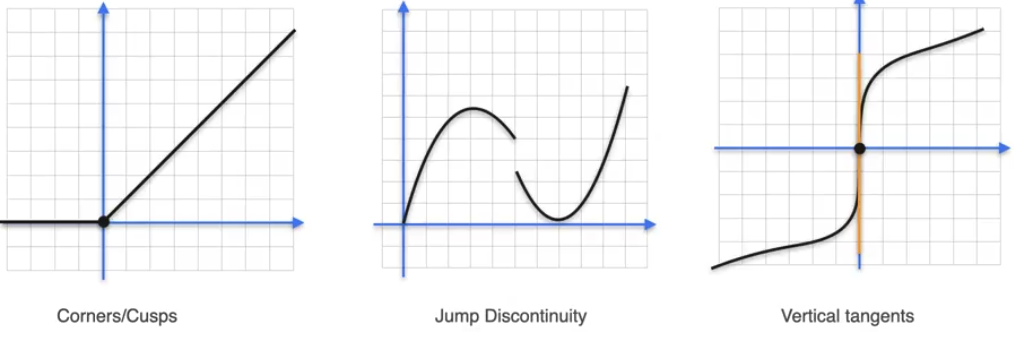

-------


# Properties of derivatives

### Multiplication by scalar
`f = cg then f' = cg'`
---
### Sum rule
`f = g + h then f' = g' + h'`
---
### Product rule
`f = gh then f' = g'h + gh'`
---
### Chain rule
`f = g(h(t) then f' = g(h) x h(t)`
---
#### also
`f = g(h(i(t)) then f' = g(h) . h(i) . i(t)`
---